In [2]:
!git log -1

commit c74eeb056e22357f9e45983fc8b04c7958c7664a (HEAD -> main, origin/main, origin/HEAD)
Author: Pierre Boyeau <pierre.boyeau@gmail.com>
Date:   Wed Apr 15 16:37:14 2026 -0400

    Refactor KEGG module processing to utilize organism-specific and universal entries for improved reaction-gene mapping. Introduce new pathway analysis and visualization modules.


```bash

commit c74eeb056e22357f9e45983fc8b04c7958c7664a (HEAD -> main, origin/main, origin/HEAD)
Author: Pierre Boyeau <pierre.boyeau@gmail.com>
Date:   Wed Apr 15 16:37:14 2026 -0400

    Refactor KEGG module processing to utilize organism-specific and universal entries for improved reaction-gene mapping. Introduce new pathway analysis and visualization modules.
```

In [13]:
import scanpy as sc
import plotnine as gg

In [4]:
EXAMPLES = [
    "M00938",  # dUTP toxicity,
    "M00120", # "coA biosynthesis"
    "M00063",  # CMP-KDO biosynthesis
    "M00121", # "heme
]

In [ ]:
adata = sc.read_h5ad("../../data/251117_genomescale_CRISPRi/sample_mix_umi200_hvg500_pc25_neighbors10_mindist0.55.h5ad")
adata.X = adata.layers["reads"]
adata = adata[~adata.obs["target"].isna()].copy()
sc.pp.highly_variable_genes(adata, n_top_genes=1000, flavor="seurat_v3")
adata = adata[:, adata.var["highly_variable"]].copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.pca(adata, use_highly_variable=True, n_comps=50)

/Users/pboyeau/miniforge3/envs/essential/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


In [16]:
sc.pp.neighbors(adata, n_neighbors=10, use_rep="X_pca")
sc.tl.umap(adata, min_dist=0.5)
adata.obs["UMAP1"] = adata.obsm["X_umap"][:, 0]
adata.obs["UMAP2"] = adata.obsm["X_umap"][:, 1]


/var/folders/lb/fgy8hrqj0kd6w1fzrws8bv1m0000gp/T/ipykernel_18602/774491668.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


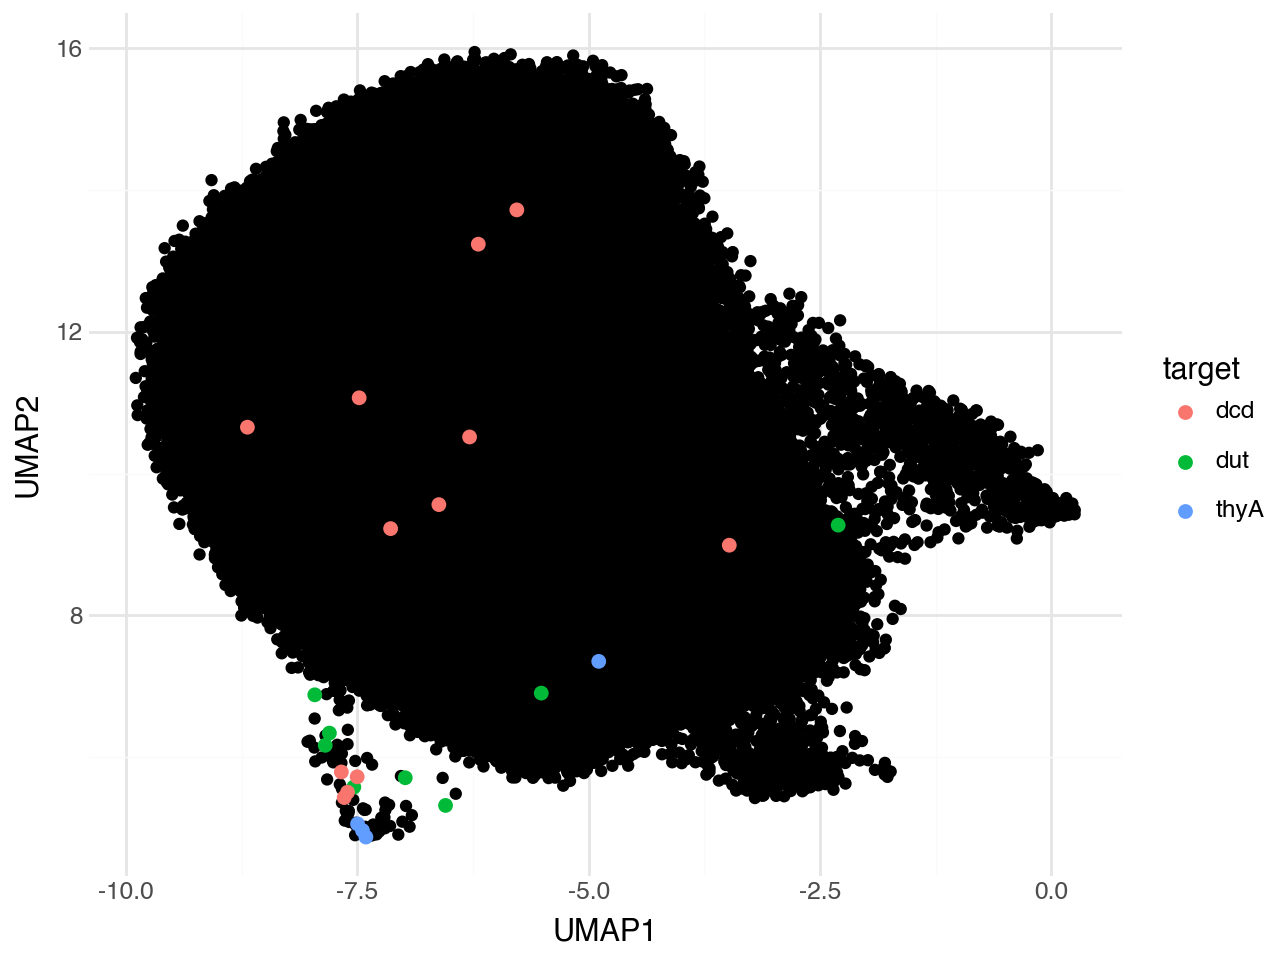

In [20]:
# dUTP toxicity
genes = ["dcd", "dut", "thyA"]

obs_subset = adata.obs.loc[lambda x: x["target"].isin(genes)]
obs_subset["target"] = obs_subset["target"].astype(str)

(
    gg.ggplot(adata.obs, gg.aes(x="UMAP1", y="UMAP2"))
    + gg.geom_point()
    + gg.geom_point(obs_subset, gg.aes(color="target"), size=2)
    + gg.theme_minimal()
)